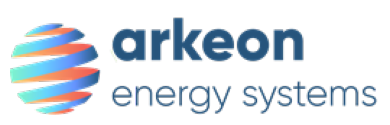

In [1]:
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

startdate = pd.Timestamp("2026-02-18")
enddate   = pd.Timestamp("2026-02-19")
nowdate = pd.Timestamp.now().normalize()

startdate_str = startdate.strftime("%Y-%m-%d")
enddate_str   = enddate.strftime("%Y-%m-%d")
nowdate_str   = nowdate.strftime("%Y-%m-%d")

generate_pdf = 0
generate_html = 1

# Display logo only
fig, ax = plt.subplots(figsize=(4, 2))

try:
    logo_path = Path('../images/logo.png')
    if logo_path.exists():
        img = mpimg.imread(logo_path)
        ax.imshow(img)
    ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Logo', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Analyse de optimisation journalier

**Site :** Pervenches-Bruyères | **Système :** PAC ARKEON

In [2]:
display(Markdown(f"**Date** : {startdate_str} → {enddate_str}\n\n---"))

**Date** : 2026-02-18 → 2026-02-19

---

In [3]:
import os
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt


# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))
from src.acquisition.get_and_export_site_data_to_csv import get_and_export_site_data_to_csv

get_and_export_site_data_to_csv(startdate)


0.29
139.67
4.2817685999999995
Acquisition de données pour la période : 2026-02-18 au 2026-02-19

Points de données d'origine : 1440
Points de données attendus : 1440
Points de données manquants remplis : 0
df_synthese_visu sauvegardé dans : c:\Users\MohamadJoumaa\Arkeon Energy SAS\08_Engineering - Documents\General\08-8 Operations and maintenance\08-7-1 Pervenche\Pilotage site\Analyse_Pilotage_Pervenches_202602\ResultsData_Site\ResultsTable_18FEB2026_site.csv


## 1. Paramètres généraux, acquisition, et traitement

### 1.1. Paramètres généraux

In [ ]:
# CELL 1: Import Libraries and Configure Project Paths
# This cell imports all necessary libraries (pandas, numpy, matplotlib) and custom modules
# for data acquisition, API access, and pricing calculations. It also sets up the project
# root path to enable proper module imports from the src/ directory.

import os
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))

from src.acquisition.acquisition import InfluxConfig, run_acquisition
from src.acquisition.endis_api import fetch_consumption_range as get_el_consumption_from_enedis
from src.transform_and_metrics.prix_MWh_elec_TTC import prix_MWh_elec_TTC
from src.transform_and_metrics.prix_MWh_elec_TTC_ENEFFIC import prix_MWh_elec_TTC_ENEFFIC


DATA_DIR = PROJECT_ROOT / "data"
ENEDIS_DIR = DATA_DIR / "ENEDIS"
OUTPUT_DIR = PROJECT_ROOT / "output"

csv_path = DATA_DIR / f"data_AllData_combined_{startdate_str}_to_{enddate_str}.csv"
json_path = ENEDIS_DIR / f"metering_data_{startdate_str}_to_{enddate_str}.json"
csv_output_path = OUTPUT_DIR / f"df_synthese_visu_{startdate_str}.csv"
optim_file = DATA_DIR / "input_optimisation" / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}.csv"

print(f"Configuration du projet...")
# print(f"  Racine du projet : {PROJECT_ROOT}")
# print(f"  Répertoire de données : {DATA_DIR}")
print(f"  Racine et répertoire de données configurés.")
print(f"  Fichiers de données configurés.")
# print(f"    - CSV InfluxDB : {csv_path.name}")
# print(f"    - JSON ENEDIS : {json_path.name}")

### 1.2. Acquisition des données système (InfluxDB)

In [ ]:
# CELL 2: Data Acquisition from InfluxDB and ENEDIS API
# This cell handles data import from two sources:
# 1. System data (temperature, energy, heat pump status) from InfluxDB database
# 2. Electricity consumption data from ENEDIS API (French grid operator)
# Both datasets are cached as CSV/JSON files to avoid redundant API calls.
# ENEDIS data is resampled from 5-minute intervals to hourly aggregations.

# IMPORT DATA FROM DATABASE AND ENEDIS API
startdate_influx = startdate - np.timedelta64(1, 'h')
enddate_influx   = enddate - np.timedelta64(1, 'h')

startdate_influx_str = startdate_influx.strftime("%Y-%m-%d %H:%M")
enddate_influx_str   = enddate_influx.strftime("%Y-%m-%d %H:%M")

print(f"Acquisition de données pour la période : {startdate_str} au {enddate_str}")
# print(f"Fichier de données InfluxDB : {csv_path.name}")
# print(f"Fichier de données ENEDIS : {json_path.name}")
print()

# Import system data from database

if os.path.exists(csv_path):
    #print(f"Le fichier données existe déjà. Chargement des données existantes...")
    df = pd.read_csv(csv_path)
else:
    #print(f"Fichier données non trouvé. Lancement de l'acquisition...")
    
    intervals = [{"start_date": startdate_str, "end_date": enddate_str, "description": "Semaine"}]

    result = run_acquisition(
        date_intervals=intervals,
        fields=[
                "TT_ext", "RH_ext", "price",
                "dis_mode", "Temp_SC_Charge",
                "DIS_STS_A_TT1", "DIS_STS_R_TT1",
                "sharky_energy",
                "DIS2_CHD_A_TT1", "DIS2_CHD_R_TT1", "Pchd_flow",
                "DIS_VRD_retour_position_opt", "DIS_CH_A_TT1", "DIS_CH_R_TT1",
                "DIS_BEL_energy_heating",
                "PAC1_energy", "PAC2_energy", "SKID_energy",
                "PAC1_power", "PAC2_power",
                "PAC1_cond_inlet", "PAC1_cond_outlet", "PAC1_modstatus",
                "PAC2_cond_inlet", "PAC2_cond_outlet", "PAC2_modstatus",
                "PAC1_user_pump", "PAC2_user_pump", "PAC1_domestic_pump", "PAC2_domestic_pump",
                "PAC1_general_alarm2", "PAC2_general_alarm2",
                "PAC1_DHW_stp", "PAC2_DHW_stp",
                ],
        use_specific_fields=True,
        output_dir="../data",
        query_mode="daily",
        data_step="1m",
        influx=InfluxConfig(),
    )
    
    # Load the newly created file
    df = pd.read_csv(csv_path)
    #print("Acquisition de données terminée et chargée.")


# Import electric consulmption data from ENEDIS api or file if already exists

if os.path.exists(json_path):
    #print(f"Le fichier données ENEDIS existe déjà. Chargement des données existantes...")
    a = 1
else:
    #print(f"Fichier données ENEDIS non trouvé. Récupération des données depuis ENEDIS...")
    result = get_el_consumption_from_enedis(startdate_str, enddate_str, output_dir="../data/ENEDIS")
    #print(result["file"])
# Load the JSON file
with open(json_path, 'r') as f:
    data = json.load(f)

# Extract the interval readings
interval_readings = data['meter_reading']['interval_reading']

# Or if you want to expand the arrays:
rows = []
for reading in interval_readings:
    rows.append({
        'date': reading['date'][0],
        'power_W': int(reading['value'][0]),
        'reactive_VAr': int(reading['value'][1])
    })
df_enedis = pd.DataFrame(rows)

df_enedis['el_energy_kWh'] = df_enedis['power_W'] * (5*60/3600) / 1000  # Assuming 5-minute intervals

df_enedis['date'] = pd.to_datetime(df_enedis['date'])

df_enedis.set_index('date', inplace=True)

df_resampled_enedis = df_enedis.resample('h').agg({
    'power_W': 'max',
    'reactive_VAr': 'max',
    'el_energy_kWh': 'sum'
}).round(2)


### 1.3. Traitements & agrégats horaires et journaliers

In [ ]:
# CELL 3: Data Processing, Metrics Calculation, and Aggregation
# This cell performs the core data processing pipeline:
# 1. Fill missing 1-minute data gaps with NaN values (for power outages)
# 2. Calculate performance metrics: COP (Coefficient of Performance), thermal energy, SPF (Seasonal Performance Factor)
# 3. Aggregate data from 1-minute to hourly and daily intervals
# 4. Merge electricity consumption data and calculate costs using French tariff structure
# 5. Generate daily statistics including temperature ranges, energy consumption, and system performance

timeStep_hours  = 60/3600

# Convert _time to datetime and remove timezone awareness
df['_time'] = pd.to_datetime(df['_time']).dt.tz_localize(None)

# Filter data to keep only dates strictly before enddate
df = df[df['_time'] < enddate]

# Set _time as index temporarily
df = df.set_index('_time')

# Create a complete datetime index with 1-minute intervals
full_time_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')

# Count missing data points
original_count = len(df)
expected_count = len(full_time_index)
missing_count = expected_count - original_count

# Reindex to fill gaps with NaN
df = df.reindex(full_time_index)

# Reset index to make _time a column again
df = df.reset_index().rename(columns={'index': '_time'})

# Print the number of lines added
print(f"Points de données d'origine : {original_count}")
print(f"Points de données attendus : {expected_count}")
print(f"Points de données manquants remplis : {missing_count}")

# Print sample of added lines (first few NaN rows)
if missing_count > 0:
   nan_rows = df[df.iloc[:, 1:].isnull().all(axis=1)]
   if len(nan_rows) > 0:
      print("\nPoints de données manquants ajoutés à ces horodatages :")
      unique_dates = {}
      for i, (idx, row) in enumerate(nan_rows.iterrows()):
         # Format datetime to Y-m-d h:00:00
         formatted_time = row['_time'].strftime('%Y-%m-%d %H:00:00')
         if formatted_time in unique_dates:
            unique_dates[formatted_time] += 1
         else:
            unique_dates[formatted_time] = 1
      
      # Print unique dates sorted with occurrence counts
      for date in sorted(unique_dates.keys()):
         print(f"  {date} ({unique_dates[date]} occurrences)")

#Add metrics columns
df['PAC1_HW'] = (df['PAC1_modstatus'] == 14)
df['PAC1_WW'] = (df['PAC1_modstatus'] == 15)
df['PAC1_defr'] = (df['PAC1_modstatus'] == 9)

df['PAC2_HW'] = (df['PAC2_modstatus'] == 14)
df['PAC2_WW'] = (df['PAC2_modstatus'] == 15)
df['PAC2_defr'] = (df['PAC2_modstatus'] == 9)


df['PAC1_th_energy'] = df.apply(lambda row: 1.16 * 14.593 * (row['PAC1_cond_outlet'] - row['PAC1_cond_inlet']) * timeStep_hours if row['PAC1_modstatus'] >= 7 else 0, axis=1)
### due to PAC2_modtatus = 13 which means "some alarms are present" the thermal energy will be calculated considerng PAC2_domestic_pump staus and not modstatus. This is because when the domestic pump is on, it means that the system is still trying to operate and provide heating, even if some alarms are present. Therefore, we will consider the thermal energy produced during these periods as well, rather than setting it to zero based on the modstatus alone.
df['PAC2_th_energy'] = df.apply(lambda row: 1.16 * 14.593 * (row['PAC2_cond_outlet'] - row['PAC2_cond_inlet']) * timeStep_hours if row['PAC2_domestic_pump'] == 1 else 0, axis=1)
df['CHD_th_energy'] = df.apply(lambda row: max(0, 1.16 * 6.1 * (row['DIS2_CHD_A_TT1'] - row['DIS2_CHD_R_TT1']) * timeStep_hours) if row['Pchd_flow'] > 4 else 0,  axis=1)
df['COP_PAC1_HW'] = df.apply(lambda row: row['PAC1_HW'] * row['PAC1_th_energy'] / (row['PAC1_power'] * timeStep_hours) if row['PAC1_power'] > 0 else 0, axis=1)
df['COP_PAC2_HW'] = df.apply(lambda row: row['PAC2_HW'] * row['PAC2_th_energy'] / (row['PAC2_power'] * timeStep_hours) if row['PAC2_power'] > 0 else 0, axis=1)
df['COP_PAC1_WW'] = df.apply(lambda row: row['PAC1_WW'] * row['PAC1_th_energy'] / (row['PAC1_power'] * timeStep_hours) if row['PAC1_power'] > 0 else 0, axis=1)
df['COP_PAC2_WW'] = df.apply(lambda row: row['PAC2_WW'] * row['PAC2_th_energy'] / (row['PAC2_power'] * timeStep_hours) if row['PAC2_power'] > 0 else 0, axis=1)

df['PAC1_th_power'] = df.apply(lambda row: 1.16 * 14.593 * (row['PAC1_cond_outlet'] - row['PAC1_cond_inlet']) if row['PAC1_modstatus'] >= 7 else 0, axis=1)
### due to PAC2_modtatus = 13 which means "some alarms are present" the thermal energy will be calculated considerng PAC2_domestic_pump staus and not modstatus. This is because when the domestic pump is on, it means that the system is still trying to operate and provide heating, even if some alarms are present. Therefore, we will consider the thermal energy produced during these periods as well, rather than setting it to zero based on the modstatus alone.
df['PAC2_th_power'] = df.apply(lambda row: 1.16 * 14.593 * (row['PAC2_cond_outlet'] - row['PAC2_cond_inlet']) if row['PAC2_domestic_pump'] == 1 else 0, axis=1)


df['recharge'] = (df['dis_mode'] == 3)
df['decharge'] = (df['dis_mode'] == 2)
df['direct'] = (df['dis_mode'] == 1)
df['T_stock'] = (df['recharge'] * df['DIS_STS_R_TT1'] + df['decharge'] * df['DIS_STS_A_TT1'])

# df['el_power_tot'] = df['el_energy_kWh'] / timeStep_hours
# df['el_power_PAC'] = (df['PAC1_energy'] + df['PAC2_energy']) / timeStep_hours
# df['conso_annexe_kW'] = df['el_power_tot'] - df['el_power_PAC']

# Forward fill price column if it exists
if 'price' in df.columns:
    df['price'] = df['price'].ffill()

# Fill T_stock based on dis_mode
df['T_stock'] = df['T_stock'].replace(0, np.nan)
# Fill only the first NaN value with the minimum of the two thermal sensors
if pd.isna(df['T_stock'].iloc[0]):
    df.loc[df.index[0], 'T_stock'] = df[['DIS_STS_R_TT1', 'DIS_STS_A_TT1']].iloc[0].min()
# Forward fill the entire table
df['T_stock'] = df['T_stock'].ffill()

df_resampled = df.set_index('_time')
# Explicitly infer object types and convert to appropriate dtypes before interpolation
df_resampled = df_resampled.infer_objects(copy=False)
# Only interpolate numeric columns to avoid FutureWarning with object dtype
numeric_cols = df_resampled.select_dtypes(include=[np.number]).columns
df_resampled[numeric_cols] = df_resampled[numeric_cols].interpolate(method='linear').round(2)

# Resample df_resampled to hourly aggregations
hourly_stats = df_resampled[["TT_ext", "RH_ext", "price",
                              "dis_mode", "Temp_SC_Charge",
                              "DIS_STS_A_TT1", "DIS_STS_R_TT1",
                              'recharge', 'decharge', 'T_stock',
                              'sharky_energy', 
                              'PAC1_energy', 'PAC2_energy', 'SKID_energy',
                              'DIS_BEL_energy_heating','CHD_th_energy',
                              'PAC1_user_pump', 'PAC2_user_pump', 'PAC1_domestic_pump', 'PAC2_domestic_pump',
                              'PAC1_th_energy', 'PAC2_th_energy',
                              'PAC1_cond_inlet', 'PAC1_cond_outlet', 'PAC2_cond_inlet', 'PAC2_cond_outlet',
                              'PAC1_DHW_stp', 'PAC2_DHW_stp',
                            ]].resample('h').agg({
                               
    'sharky_energy': lambda x: x.iloc[-1] - x.iloc[0],
    'DIS_BEL_energy_heating': lambda x: x.iloc[-1] - x.iloc[0],
    'CHD_th_energy': 'sum',
    'PAC1_energy': lambda x: x.iloc[-1] - x.iloc[0],
    'PAC2_energy': lambda x: x.iloc[-1] - x.iloc[0],
    'SKID_energy': lambda x: x.iloc[-1] - x.iloc[0],
    'PAC1_user_pump': lambda x: x.sum() * timeStep_hours,
    'PAC2_user_pump': lambda x: x.sum() * timeStep_hours,
    'PAC1_domestic_pump': lambda x: x.sum() * 2.2 * timeStep_hours,
    'PAC2_domestic_pump': lambda x: x.sum() * 2.2 * timeStep_hours,
    'PAC1_th_energy': lambda x: x.sum(),
    'PAC2_th_energy': lambda x: x.sum(),
    'TT_ext': 'mean',
    'RH_ext': 'mean',
    'price': 'mean' ,
    'recharge': ['first', 'mean'],
    'decharge': ['first', 'mean'],
    'Temp_SC_Charge':['first'],
    'T_stock': [lambda x: x.iloc[5] if len(x) > 5 else x.iloc[0], 'last'],
    'PAC1_cond_inlet': 'mean','PAC1_cond_outlet': 'mean', 'PAC2_cond_inlet':'mean', 'PAC2_cond_outlet': 'mean',
    'PAC1_DHW_stp': 'max', 'PAC2_DHW_stp': 'max',

}).round(2)

# Flatten column names
hourly_stats.columns = ['sharky_energy',
    'DIS_BEL_energy_heating',
    'CHD_th_energy',
    'PAC1_energy',
    'PAC2_energy',
    'SKID_energy',
    'PAC1_user_pump',
    'PAC2_user_pump',
    'PAC1_domestic_pump',
    'PAC2_domestic_pump',
    'PAC1_th_energy',
    'PAC2_th_energy',
    'TT_ext',
    'RH_ext',
    'price_mean' ,
    'recharge_first', 'recharge_mean',
    'decharge_first', 'decharge_mean',
    'Temp_SC_Charge_first',
    'T_stock_first', 'T_stock_last',
    'PAC1_cond_inlet', 'PAC1_cond_outlet', 'PAC2_cond_inlet', 'PAC2_cond_outlet',
    'PAC1_DHW_stp', 'PAC2_DHW_stp',
    ]
#display(hourly_stats)

# Flatten MultiIndex columns
#hourly_stats.columns = ['_'.join(col).strip('_') for col in hourly_stats.columns.values]

# Merge energy_kWh from ENEDIS data
hourly_stats = hourly_stats.merge(df_resampled_enedis[['el_energy_kWh']], left_index=True, right_index=True, how='left')

# Some NaN values are present, for now the solution is to fill them through interpolation. 
# Should be discussed
hourly_stats = hourly_stats.interpolate(method='linear').round(2)


hourly_stats.columns.tolist()
# Apply prix_MWh_elec_TTC function to calculate electricity prices
# Use prix_MWh_elec_TTC_ENEFFIC for dates after 21/12/2026
hourly_stats[['el_price_fixed', 'el_price_variable']] = hourly_stats.apply(
   lambda row: pd.Series(
      prix_MWh_elec_TTC_ENEFFIC(row.name, row['price_mean'])
      if row.name >= pd.Timestamp('2025-12-21')
      else prix_MWh_elec_TTC(row.name, row['price_mean']) 
   ), axis=1
)

#df_resampled_enedis.to_csv("test.csv")
hourly_stats['el_price_variable'] = hourly_stats['el_price_variable']/1000
hourly_stats['el_energy_cost'] = (hourly_stats['el_price_fixed'] + hourly_stats['el_price_variable'] * hourly_stats['el_energy_kWh']).round(2)

display(hourly_stats.head())

In [ ]:
# DEBUG: print head of hourly_stats
print('hourly_stats:')
try:
    display(hourly_stats.head())
except Exception as e:
    print('Error displaying hourly_stats:', e)

In [ ]:
# Initialisation du DataFrame de synthèse avec le même index
df_synthese_visu = pd.DataFrame(index=hourly_stats.index)

# --- Informations de temps ---
df_synthese_visu['Heure'] = hourly_stats.index.hour
#df_synthese_visu['time'] = hourly_stats['_time']

# --- Températures et Stock ---
df_synthese_visu['T_ext'] = hourly_stats['TT_ext']
df_synthese_visu['Tst'] = hourly_stats['T_stock_first']
# Moyenne des entrées/sorties condenseurs
df_synthese_visu['Tcond'] = hourly_stats[['PAC1_DHW_stp', 'PAC2_DHW_stp']].max(axis=1)
df_synthese_visu['Cond_prod'] = -1.6 * hourly_stats['TT_ext'] + 49
# Calcul de l'énergie stockée (formule : 1.16 * Volume * deltaT)
df_synthese_visu['S_stock'] = 1.16 * 5 * (hourly_stats['T_stock_first'] - 15)

# --- Flux et Puissances Thermiques ---
df_synthese_visu['Q_base'] = hourly_stats['sharky_energy']
df_synthese_visu['Qdis'] = hourly_stats['decharge_mean'] * hourly_stats['sharky_energy']
df_synthese_visu['Quse'] = hourly_stats['sharky_energy'] - df_synthese_visu['Qdis']
df_synthese_visu['Qch'] = hourly_stats['recharge_mean'] * (df_synthese_visu['Q_base'] - hourly_stats['sharky_energy'])
df_synthese_visu['Qww'] = 0
df_synthese_visu['Qpin'] = 0

# --- Mode select ---
df_synthese_visu['m_pac_ch'] = hourly_stats['recharge_first']
df_synthese_visu['m_dis'] = hourly_stats['decharge_first']
df_synthese_visu['m_ww'] = 0

# --- Puissances Électriques ---
df_synthese_visu['P_ww'] = 0
df_synthese_visu['P_pin'] = 0
df_synthese_visu['Elec_tot'] = hourly_stats['el_energy_kWh']
df_synthese_visu['Conso'] =  hourly_stats['el_energy_kWh'] * hourly_stats['el_price_variable']


# --- Cas baseline ---
df_synthese_visu['P_base'] = 0
df_synthese_visu['Elec_base'] = 0
df_synthese_visu['Conso_base'] = 0
df_synthese_visu['P_chrg'] = df_synthese_visu['Elec_tot'] - df_synthese_visu['Elec_base']
df_synthese_visu['NegaWatts'] = 0
df_synthese_visu['Gain_spot'] = 0


# --- Prix et Gains ---
df_synthese_visu['EURMWH_SPOT'] = hourly_stats['price_mean']
df_synthese_visu['EURKWH_variable'] = hourly_stats['el_price_variable']
df_synthese_visu['Cost_hour'] = hourly_stats['el_energy_cost']

In [ ]:
# DEBUG: print head of hourly_stats
print('df_synthese_visu:')
try:
    display(df_synthese_visu.head())
except Exception as e:
    print('Error displaying df_synthese_visu:', e)

In [ ]:

# Reorder columns to match the required format
column_order = ['Heure', 'T_ext', 'Q_base', 'EURMWH_SPOT', 'EURKWH_variable', 'Tst', 'Tcond', 
                'Cond_prod', 'S_stock', 'm_pac_ch', 'm_dis', 'm_ww', 'Quse', 'Qdis', 'Qch', 
                'Qww', 'Qpin', 'P_base', 'P_chrg', 'P_ww', 'P_pin', 'Elec_tot', 'Conso', 
                'Elec_base', 'Conso_base', 'NegaWatts', 'Gain_spot', 'Cost_hour']

df_synthese_visu_export = df_synthese_visu[column_order].copy()
df_synthese_visu_export.to_csv(csv_output_path, index=False, sep=';')

print(f"df_synthese_visu sauvegardé dans : {csv_output_path}")

In [ ]:
results_optim_detail = pd.read_csv(optim_file, sep=';')
display(results_optim_detail.head())

## 2. Visualisation : 

In [ ]:
# Create a comparison plot of T_ext from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot T_ext from both dataframes
ax.plot(x, results_optim_detail['T_ext'], 
    marker='o', linewidth=2, label='T_ext (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['T_ext'], 
    marker='s', linewidth=2, label='T_ext (réel)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison T_ext : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(24)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques T_ext:")
print(f"Optimisation  - Mean: {results_optim_detail['T_ext'].mean():.2f}°C, Min: {results_optim_detail['T_ext'].min():.2f}°C, Max: {results_optim_detail['T_ext'].max():.2f}°C")
print(f"Réel - Mean: {df_synthese_visu['T_ext'].mean():.2f}°C, Min: {df_synthese_visu['T_ext'].min():.2f}°C, Max: {df_synthese_visu['T_ext'].max():.2f}°C")

In [ ]:
# Create a comparison plot of Q_bqse from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot Q_base from both dataframes
ax.plot(x, results_optim_detail['Q_base'], 
    marker='o', linewidth=2, label='Q_base (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['Q_base'], 
    marker='s', linewidth=2, label='Q_base (réel)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison Q_base : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Puissance thermique (kW)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(24)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques Q_base:")
print(f"Optimisation  - Mean: {results_optim_detail['Q_base'].mean():.2f} kW, Min: {results_optim_detail['Q_base'].min():.2f} kW, Max: {results_optim_detail['Q_base'].max():.2f} kW, Sum: {results_optim_detail['Q_base'].sum():.2f} kWh")
print(f"Réel - Mean: {df_synthese_visu['Q_base'].mean():.2f} kW, Min: {df_synthese_visu['Q_base'].min():.2f} kW, Max: {df_synthese_visu['Q_base'].max():.2f} kW, Sum: {df_synthese_visu['Q_base'].sum():.2f} kWh")

In [ ]:
# Create a comparison plot of EURMWH_SPOT from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot EURMWH_SPOT from both dataframes
ax.plot(x, results_optim_detail['EURMWH_SPOT'], 
    marker='o', linewidth=2, label='EURMWH_SPOT (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['EURMWH_SPOT'], 
    marker='s', linewidth=2, label='EURMWH_SPOT (réel)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison EURMWH_SPOT : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('EUR/MWh')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques EURMWH_SPOT:")
print(f"Optimisation  - Mean: {results_optim_detail['EURMWH_SPOT'].mean():.2f} EUR/MWh, Min: {results_optim_detail['EURMWH_SPOT'].min():.2f} EUR/MWh, Max: {results_optim_detail['EURMWH_SPOT'].max():.2f} EUR/MWh")
print(f"Réel - Mean: {df_synthese_visu['EURMWH_SPOT'].mean():.2f} EUR/MWh, Min: {df_synthese_visu['EURMWH_SPOT'].min():.2f} EUR/MWh, Max: {df_synthese_visu['EURMWH_SPOT'].max():.2f} EUR/MWh")

In [ ]:
# Create a comparison plot of EURKWH_variable from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot EURKWH_variable from both dataframes
ax.plot(x, results_optim_detail['EURKWH_variable'], 
    marker='o', linewidth=2, label='EURKWH_variable (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['EURKWH_variable'], 
    marker='s', linewidth=2, label='EURKWH_variable (réel)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison EURKWH_variable : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('EUR/kWh')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques EURKWH_VARIABLE:")
print(f"Optimisation  - Mean: {results_optim_detail['EURKWH_variable'].mean():.2f} EUR/kWh, Min: {results_optim_detail['EURKWH_variable'].min():.2f} EUR/kWh, Max: {results_optim_detail['EURKWH_variable'].max():.2f} EUR/kWh")
print(f"Réel - Mean: {df_synthese_visu['EURKWH_variable'].mean():.2f} EUR/kWh, Min: {df_synthese_visu['EURKWH_variable'].min():.2f} EUR/kWh, Max: {df_synthese_visu['EURKWH_variable'].max():.2f} EUR/kWh")

In [ ]:
# Create a comparison plot of Tst from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot Tst from both dataframes
ax.plot(x, results_optim_detail['Tst'], 
    marker='o', linewidth=2, label='Tst (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['Tst'], 
    marker='s', linewidth=2, label='Tst (réel)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison Tst : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques Tst:")
print(f"Optimisation  - Mean: {results_optim_detail['Tst'].mean():.2f} °C, Min: {results_optim_detail['Tst'].min():.2f} °C, Max: {results_optim_detail['Tst'].max():.2f} °C")
print(f"Réel - Mean: {df_synthese_visu['Tst'].mean():.2f} °C, Min: {df_synthese_visu['Tst'].min():.2f} °C, Max: {df_synthese_visu['Tst'].max():.2f} °C")

# Create a comparison plot of S_stock from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x, results_optim_detail['S_stock'], 
    marker='o', linewidth=2, label='S_stock (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['S_stock'], 
    marker='s', linewidth=2, label='S_stock (réel)', color='#FF9166')

ax.set_title('Comparaison S_stock : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Energie stockée (kWh)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nStatistiques S_stock:")
print(f"Optimisation  - Mean: {results_optim_detail['S_stock'].mean():.2f} kWh, Min: {results_optim_detail['S_stock'].min():.2f} kWh, Max: {results_optim_detail['S_stock'].max():.2f} kWh")
print(f"Réel - Mean: {df_synthese_visu['S_stock'].mean():.2f} kWh, Min: {df_synthese_visu['S_stock'].min():.2f} kWh, Max: {df_synthese_visu['S_stock'].max():.2f} kWh")

In [ ]:
# Create a comparison plot of Cond_prod from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot Cond_prod from both dataframes
ax.plot(x, results_optim_detail['Cond_prod'], 
    marker='o', linewidth=2, label='Cond_prod (optimisation)', color="#6694FFFF")
ax.plot(x, df_synthese_visu['Cond_prod'], 
    marker='s', linewidth=2, label='Cond_prod (réel)', color="#FF9166FF")

# Customize the plot
ax.set_title('Comparaison Cond_prod : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Energie (kWh)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques Cond_prod:")
print(f"Optimisation  - Mean: {results_optim_detail['Cond_prod'].mean():.2f} kWh, Min: {results_optim_detail['Cond_prod'].min():.2f} kWh, Max: {results_optim_detail['Cond_prod'].max():.2f} kWh")
print(f"Réel - Mean: {df_synthese_visu['Cond_prod'].mean():.2f} kWh, Min: {df_synthese_visu['Cond_prod'].min():.2f} kWh, Max: {df_synthese_visu['Cond_prod'].max():.2f} kWh")
print(f"Optimisation  - Mean: {results_optim_detail['Cond_prod'].mean():.2f} kWh, Min: {results_optim_detail['Cond_prod'].min():.2f} kWh, Max: {results_optim_detail['Cond_prod'].max():.2f} kWh")
print(f"Réel - Mean: {df_synthese_visu['Cond_prod'].mean():.2f} kWh, Min: {df_synthese_visu['Cond_prod'].min():.2f} kWh, Max: {df_synthese_visu['Cond_prod'].max():.2f} kWh")

In [ ]:
# Create a comparison plot of Elec_tot from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot Elec_tot from both dataframes as bars
ax.bar(x - 0.2, results_optim_detail['Elec_tot'], 
    width=0.4, label='Elec_tot (optimisation)', color="#6694FF83")
ax.bar(x + 0.2, df_synthese_visu['Elec_tot'], 
    width=0.4, label='Elec_tot (réel)', color="#FF91667F")

# Customize the plot
ax.set_title('Comparaison Elec_tot : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Energie électrique totale (kWh)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques Elec_tot:")
print(f"Optimisation  - Mean: {results_optim_detail['Elec_tot'].mean():.2f} kWh, Min: {results_optim_detail['Elec_tot'].min():.2f} kWh, Max: {results_optim_detail['Elec_tot'].max():.2f} kWh")
print(f"Réel - Mean: {df_synthese_visu['Elec_tot'].mean():.2f} kWh, Min: {df_synthese_visu['Elec_tot'].min():.2f} kWh, Max: {df_synthese_visu['Elec_tot'].max():.2f} kWh")

In [ ]:
# Create a comparison plot of Cost_hour from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_optim_detail))

# Plot Cost_hour from both dataframes
ax.plot(x, results_optim_detail['Cost_hour'], 
    marker='o', linewidth=2, label='Cost_hour (optimisation)', color='#6694FF')
ax.plot(x, df_synthese_visu['Cost_hour'], 
    marker='s', linewidth=2, label='Cost_hour (réel)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison Cost_hour : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Coût horaire (€)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques Cost_hour:")
print(f"Optimisation  - Mean: {results_optim_detail['Cost_hour'].mean():.2f} €, Min: {results_optim_detail['Cost_hour'].min():.2f} €, Max: {results_optim_detail['Cost_hour'].max():.2f} €, Sum: {results_optim_detail['Cost_hour'].sum():.2f} €")
print(f"Réel - Mean: {df_synthese_visu['Cost_hour'].mean():.2f} €, Min: {df_synthese_visu['Cost_hour'].min():.2f} €, Max: {df_synthese_visu['Cost_hour'].max():.2f} €, Sum: {df_synthese_visu['Cost_hour'].sum():.2f} €")
